In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import sklearn
import matplotlib.pyplot as pltpipi
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import datetime
from scipy.optimize import curve_fit
from functools import partial


from helpers import file_data_processing
from helpers import config
from helpers import preprocessing

In [2]:
SYSTEM_RATED_POWER_DICT = {"HEL" : config.rated_power_helsinki*1000,
                             "KUO" : config.rated_power_kuopio*1000,
                             "SOT-20" : config.rated_power_sodankyla*1000,
                             "SOT-90" : config.rated_power_sodankyla*1000,
                             "TKU" : config.rated_power_turku*1000}



In [3]:
def calculate_predictions_with_plr_losses(data, plr_value, list_of_models, list_of_renamed_models):
    for i in range(len(list_of_models)):
        data = preprocessing.calculate_power_with_plr_losses(data, plr_value, list_of_models[i], list_of_renamed_models[i], min(data.index))
    
    return data

In [4]:
def estimate_huld(rated_power, data, radiation_col_name="poa_rc", power_col_name="power", training_year=0):
    """
    Huld regression model is a predictive model using module temperature and in-plane irradiance [1].
    Authors fit the model to indoor data but here outdoor data is used. Coefficients are obtained from
    one training year, after which performance losses can be tracked by comparing the measured powers to
    predicted ones.
    Args:
        data (Pandas DataFrame): input dataframe
        training_year (int): The number of the year the data is trained. If 0, default coefficients k1-k6 will be used.
    Returns:
 
    References:
        [1] Thomas Huld et al. A power-rating model for crystalline silicon PV modules,
        Solar Energy Materials and Solar Cells, Volume 95, Issue 12, 2011, Pages 3359-3369, ISSN 0927-0248,
        https://doi.org/10.1016/j.solmat.2011.07.026.
    """
 
    # data = data.dropna()  # Drop nan values rowwise to be able to perform the fitting
 
    # If module temperature column not in data, use cell temperature
    if 'module_temp' not in data.columns:
        data['module_temp'] = data['cell_temp'].copy()

    # huld 2010 constants
    k1 = -0.017162
    k2 = -0.040289
    k3 = -0.004681
    k4 = 0.000148
    k5 = 0.000169
    k6 = 0.000005

    default_coeffs = [k1, k2, k3, k4, k5, k6]

    # If training years are given, fit the coefficients. Otherwise, use the default coefficients for predictions.
    if training_year > 0:
        training_data = data[data.index <= data.index[0] + datetime.timedelta(days=365*training_year)]
        testing_data = data[data.index > data.index[0] + datetime.timedelta(days=365*training_year)]

        print(f"Training data len: {training_data.shape[0]}")

        i, t, p = (training_data[radiation_col_name]).values.astype('float64'), \
                (training_data['module_temp']).values.astype('float64'), \
                (training_data[power_col_name]).values.astype('float64')
        # Fit to data and find the coefficients
        #coeffs, pcov = curve_fit(partial(_huld, config.rated_power*1000), [i, t], p)
        #coeffs, pcov = curve_fit(f=_huld,
        #                         xdata=[config.rated_power*1000, [i, t]],
        #                         ydata=p,
        #                         method="lm")
        coeffs, pcov = curve_fit(f=partial(_huld, rated_power), 
                                 xdata=[i, t], 
                                 ydata=p,
                                 p0=default_coeffs,
                                 method="lm")

        print(f"Huld fitted coefficients (scaled): {np.array(coeffs) / rated_power}")
    else:
        coeffs = default_coeffs
        testing_data = data
        
    # Make the predictions for the whole dataset (including the years used for fitting)
    pred_p = _huld(rated_power, [data[radiation_col_name], data['module_temp']],
                   coeffs[0], coeffs[1], coeffs[2], coeffs[3], coeffs[4], coeffs[5])
   
    # # Calculate the performance points by dividing output power with the predicted power
    # norm_p = data.power / pred_p.values
    # 
    # return G_weighted_aggregation(interval, data['poa'], norm_p)
    return pred_p


def _huld(rated_power, X, k1, k2, k3, k4, k5, k6):
    """
    Args:
        p_rated (float): nameplate power rating of the PV system in watts
        X:
        k1-k6:
    Returns:
    """
    ref_temp = 25
    ref_irrad = 1000
 
    i, t = X
    G = i / ref_irrad
    G[G <= 0] = 0.000001 # Make zeros small floats for log
    T = t - ref_temp
    pred_p = G*(rated_power + k1*np.log(G) + k2*np.log(G)**2 + k3*T + k4*T*np.log(G) + k5*T*np.log(G)**2 + k6*T**2)
   
    return pred_p

In [5]:
def find_project_root(start: Path = None) -> Path:
    """
    Walk upwards until we find a folder that contains 'data'.
    """
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    raise FileNotFoundError("Could not find project root containing 'data'.")

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models" / "hgbr"

ROOT, DATA_DIR, MODELS_DIR

(WindowsPath('c:/Users/viantt/git2/EUPVSEC-26'),
 WindowsPath('c:/Users/viantt/git2/EUPVSEC-26/data'),
 WindowsPath('c:/Users/viantt/git2/EUPVSEC-26/models/hgbr'))

In [6]:
def pick_system_file(system_tag, folder):
    folder_path = DATA_DIR / folder
    matches = sorted(folder_path.glob(f"*{system_tag}*.csv"))
    if not matches:
        raise FileNotFoundError(f"No CSV found for system tag '{system_tag}' in {folder_path}")
    return matches[0]


from pathlib import Path

def pick_model(system_code, folder, scenario, model_type = "hgbr"):
    """
    system_code: HEL, KUO, SOT-20, SOT-90, TKU.
    folder: "scenario_1", "scenario_2", or "scenario_3
    model_type: 'hgbr' or 'mlp'
    """
    pattern = f"{model_type}_pipeline_{system_code}_{scenario}.pkl"

    folder_dir = Path(MODELS_DIR) / folder  # robust Path joining
    candidates = sorted(folder_dir.glob(pattern))

    if not candidates:
        raise FileNotFoundError(f"No model files matching '{pattern}' in {folder_dir}")

    # Return most recently modified model
    return max(candidates, key=lambda p: p.stat().st_mtime)


def get_expected_features(pipeline):
    """
    Try a few common sklearn attributes to retrieve expected feature names.
    """
    # Case 1: pipeline saved with feature_names_in_
    if hasattr(pipeline, "feature_names_in_"):
        return list(pipeline.feature_names_in_)
    
    # Case 2: pipeline is a Pipeline and first step might have feature_names_in_
    if hasattr(pipeline, "named_steps"):
        for step in pipeline.named_steps.values():
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
    
    # If we can't infer, return None and we'll fall back to numeric columns
    return None


def build_X(df: pd.DataFrame, pipeline, scenario):
    expected = get_expected_features(pipeline)
    if expected is not None:
        missing = [c for c in expected if c not in df.columns]

        # If system doesn't measure POA, POA comp(uted) needs to be used
        if ("poa_comp_rc" in df.columns) & ("poa_rc" in missing):
            df["poa_rc"] = df["poa_comp_rc"]
            missing.remove("poa_rc")
        if ("poa_comp" in df.columns) & ("poa" in missing):
            df["poa"] = df["poa_comp"]
            missing.remove("poa")

        if missing:
            raise ValueError(
                "Your data is missing columns expected by the model:\n"
                + "\n".join(missing[:50]) + ("" if len(missing) <= 50 else f"\n... (+{len(missing)-50} more)")
            )

        X = df[expected].copy()
        
        return X
    
    # Fallback: use numeric columns except obvious targets
    drop_candidates = {"y", "target", "pv", "PV", "power", "Power", "label"}
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [c for c in numeric_cols if c not in drop_candidates]
    if len(numeric_cols) == 0:
        raise ValueError("Could not infer features; no numeric columns found.")
    return df[numeric_cols].copy()


In [7]:
def estimate_empirical_models(data, rated_power, radiation_col_name, power_col_name, training_year=1):
    data["Huld_gen"] = estimate_huld(rated_power, data, radiation_col_name=radiation_col_name, power_col_name=power_col_name)
    data["Huld_fit"] = estimate_huld(rated_power, data, radiation_col_name=radiation_col_name, power_col_name=power_col_name, training_year=training_year)
    
    return data

#df_hel_scenario_1 = estimate_empirical_models(df_hel_scenario_1, SYSTEM_RATED_POWER_DICT["HEL"], radiation_col_name="poa_rc", power_col_name="power", training_year=1)
#df_hel_scenario_2 = estimate_empirical_models(df_hel_scenario_2, SYSTEM_RATED_POWER_DICT["HEL"], radiation_col_name="poa_rc", power_col_name="power", training_year=1)
#df_hel_scenario_3 = estimate_empirical_models(df_hel_scenario_3, SYSTEM_RATED_POWER_DICT["HEL"], radiation_col_name="poa_rc", power_col_name="power", training_year=1)

In [8]:
SYSTEM_MAP = {
    "Helsinki": ("HEL", "FMI_Helsinki"),
    "Kuopio": ("KUO", "FMI_Kuopio"),
    "KTK": ("TKU", "KTK_South"),
    "Sodankyla_20deg": ("SOT-20", "FMI_Sodankyla_20deg"),
    "Sodankyla_90deg": ("SOT-90", "FMI_Sodankyla_90deg"),
}

def run_system(system_name, folder, scenario, model_type_list=None, sep=",", save_df_path=None, plr=None):
    system_code, file_tag = SYSTEM_MAP[system_name]
    
    # Pick data file
    search_dir = DATA_DIR / "original" / folder
    matches = sorted(search_dir.glob(f"*{file_tag}*.csv"))

    if not matches:
        raise FileNotFoundError(f"No data file for {system_name} in {search_dir}")

    if plr is not None:
        matches = [m for m in matches if f"PLR-{plr}" in str(m)]

    data_path = matches[0]
    df = pd.read_csv(data_path, sep=sep)

    df_out = df.copy()
    df_out = df_out.set_index("utctime")
    df_out.index = pd.to_datetime(df_out.index, errors="coerce")
    
    # Pick model
    for model_type in model_type_list:
        # model_gen_path = pick_model(system_code=system_code, folder=folder, model_type=model_type)
        # model_gen = joblib.load(model_gen_path)
        if model_type == "Huld":
            print("Calculating Huld model predicions")
            if (scenario == "scenario_1") | (scenario == "scenario_2"):
                if "poa" in df_out.columns:
                    radiation_col_name = "poa"
                else:
                    radiation_col_name = "poa_comp"
    
            elif (scenario == "scenario_3") | (scenario == "scenario_4"):
                if "poa_rc" in df_out.columns:
                    radiation_col_name = "poa_rc"
                else:
                    radiation_col_name = "poa_comp_rc"

            power_col_name = "power_without_plr_losses"
                
            df_out = estimate_empirical_models(df_out, 
                                            SYSTEM_RATED_POWER_DICT[system_code], 
                                            radiation_col_name=radiation_col_name, 
                                            power_col_name=power_col_name, training_year=1)
            
        elif model_type == "hgbr":
            print("Calculating hgbr model predicions")
            model_fit_path = pick_model(system_code=system_code, folder=folder, model_type=model_type, scenario=scenario)

            model_fit = joblib.load(model_fit_path)       

            # Predict
            # X_gen = build_X(df, model_gen)
            # pred_gen = model_gen.predict(X_gen)

            X_fit = build_X(df, model_fit, scenario)
            pred_fit = model_fit.predict(X_fit)

        # df_out[f"{model_type}_gen"] = pred_gen * SYSTEM_RATED_POWER_DICT[system_code]
            df_out[f"{model_type}_fit"] = pred_fit * SYSTEM_RATED_POWER_DICT[system_code]
        else:
            print(f"Unknown model type {model_type}")



    print(system_name)
    print(config.plr_value)
    print("-------------")

    starting_date = "2021-08-01"
    ending_date = "2021-08-03"

    plt.plot(df_out.loc[(df_out.index >= starting_date) & (df_out.index <= ending_date), "hgbr_fit"], alpha=0.5, label="before PLR losses")

    df_out = calculate_predictions_with_plr_losses(df_out, config.plr_value, ["Huld_gen", "Huld_fit", "hgbr_fit"], ["Huld_gen_plr_corr", "Huld_fit_plr_corr", "hgbr_fit_plr_corr"])

    plt.plot(df_out.loc[(df_out.index >= starting_date) & (df_out.index <= ending_date), "hgbr_fit_plr_corr"], alpha=0.5, label="after PLR losses")
    plt.legend(loc="upper right")

    plt.show()

    if save_df_path:
            df_out.to_csv(f"{save_df_path}/{file_tag}_{scenario}.csv")
    
    return df_out



Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 219165
Huld fitted coefficients (scaled): [ 0.19750572  0.07292982  0.00613301  0.0013596  -0.00041604 -0.00070269]
Helsinki
-0.0
-------------


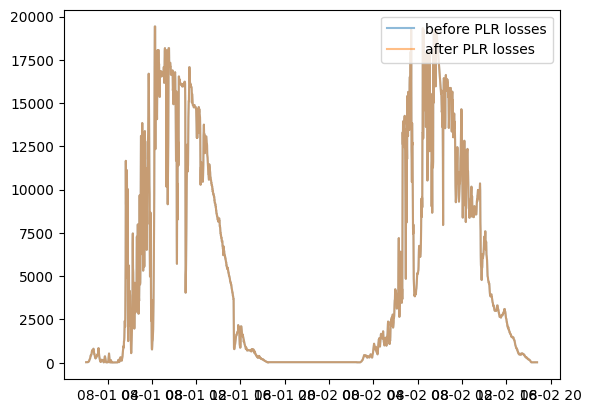

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 149096
Huld fitted coefficients (scaled): [ 0.19648994  0.08143551  0.00038376 -0.00087059  0.0012865  -0.0003043 ]
Kuopio
-0.0
-------------


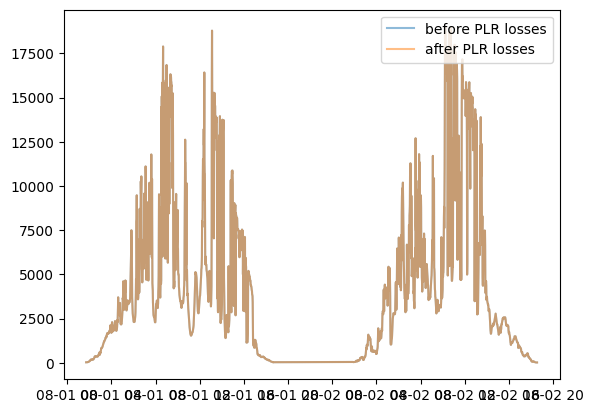

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 200357
Huld fitted coefficients (scaled): [ 4.35382530e-01  2.12558457e-01  2.27017278e-03  1.56667240e-02
  9.56394600e-03 -4.02183959e-04]
Sodankyla_20deg
-0.0
-------------


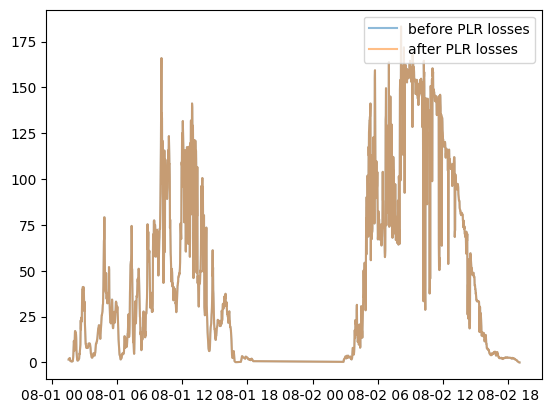

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 198309
Huld fitted coefficients (scaled): [ 2.68256487e-01  6.13643032e-02 -2.72618885e-03  5.13471608e-03
  2.54580188e-03 -1.90762378e-04]
Sodankyla_90deg
-0.0
-------------


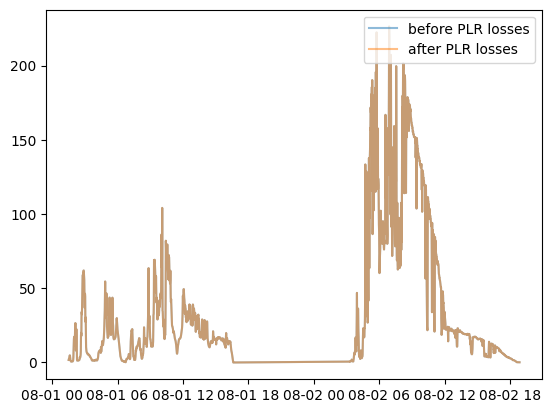

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 40165
Huld fitted coefficients (scaled): [ 0.36398742  0.15012415  0.00277649 -0.0071464  -0.00127072 -0.00051709]
KTK
-0.0
-------------


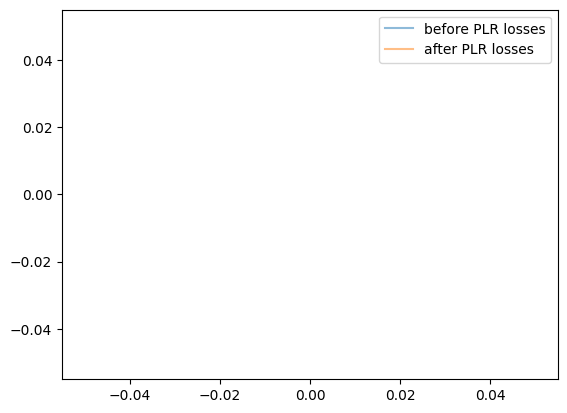

In [9]:
scenario = "scenario_1"

config.set_params_helsinki(scenario)

df_hel_scenario_1 = run_system(
    system_name="Helsinki", 
    folder=scenario, 
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_kuopio(scenario)

df_kuo_scenario_1 = run_system(
    system_name="Kuopio", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_sodankyla_20(scenario)

df_sod20_scenario_1 = run_system(
    system_name="Sodankyla_20deg", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_sodankyla_90(scenario)

df_sod90_scenario_1 = run_system(
    system_name="Sodankyla_90deg", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_turku(scenario)

df_tku_scenario_1 = run_system(
    system_name="KTK", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 218083
Huld fitted coefficients (scaled): [ 0.20426657  0.07804766  0.00682389  0.00307759  0.00024824 -0.00071532]
Helsinki
-0.0
-------------


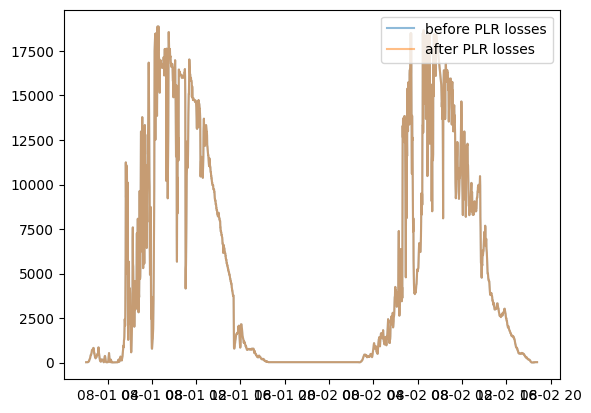

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 147491
Huld fitted coefficients (scaled): [ 0.20402511  0.08652897  0.00060698 -0.00027636  0.00158149 -0.00030738]
Kuopio
-0.0
-------------


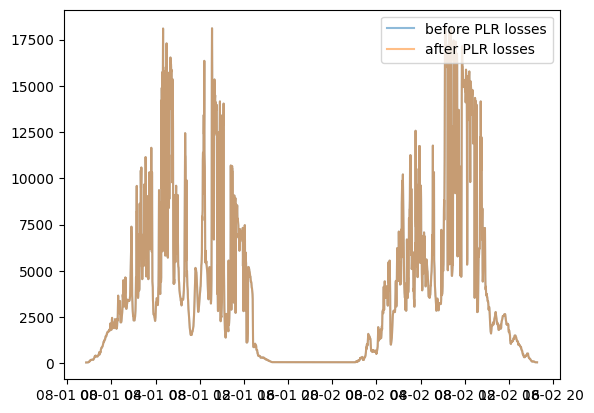

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 198455
Huld fitted coefficients (scaled): [ 4.35735610e-01  2.13559665e-01  2.22716015e-03  1.56924052e-02
  9.64063987e-03 -4.01628231e-04]
Sodankyla_20deg
-0.0
-------------


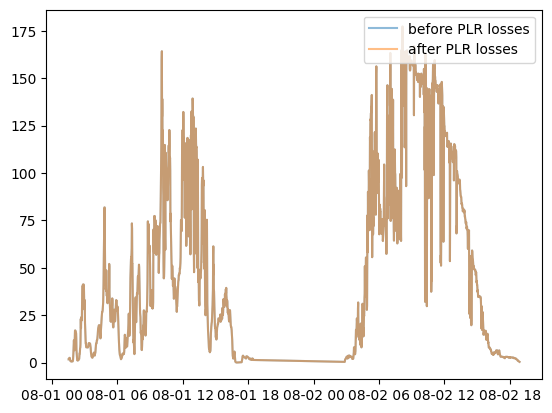

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 195359
Huld fitted coefficients (scaled): [ 2.69328159e-01  6.22506029e-02 -2.70574071e-03  5.24609067e-03
  2.63152186e-03 -1.88082922e-04]
Sodankyla_90deg
-0.0
-------------


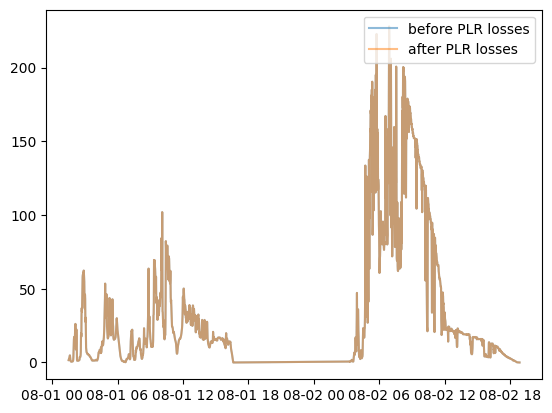

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 37242
Huld fitted coefficients (scaled): [ 2.63774879e-01  1.04855834e-01 -9.67833281e-03 -1.19090607e-02
 -1.87879208e-04  5.81279179e-06]
KTK
-0.0
-------------


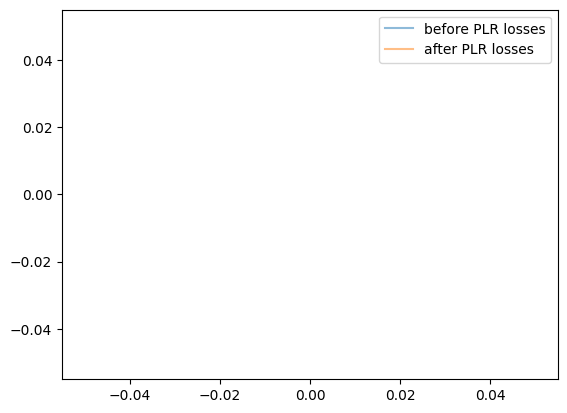

In [10]:
scenario = "scenario_2"

config.set_params_helsinki(scenario)

df_hel_scenario_2 = run_system(
    system_name="Helsinki", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_kuopio(scenario)

df_kuo_scenario_2 = run_system(
    system_name="Kuopio", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_sodankyla_20(scenario)

df_sod20_scenario_2 = run_system(
    system_name="Sodankyla_20deg", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_sodankyla_90(scenario)

df_sod90_scenario_2 = run_system(
    system_name="Sodankyla_90deg", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_turku(scenario)

df_tku_scenario_2 = run_system(
    system_name="KTK", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 177993
Huld fitted coefficients (scaled): [ 1.27699820e-01  5.82789136e-02 -6.35551713e-03 -5.09987593e-03
  7.03588272e-04 -5.68281066e-06]
Helsinki
-0.33
-------------


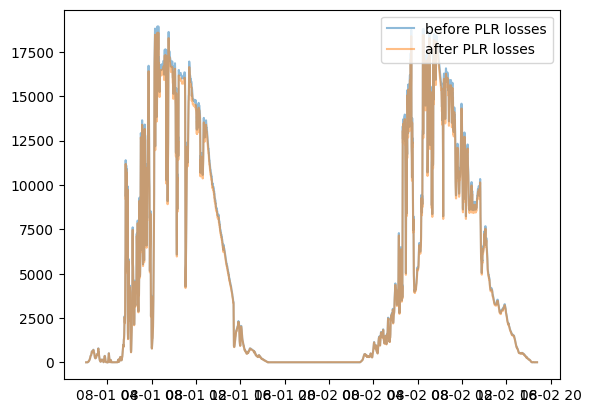

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 125409
Huld fitted coefficients (scaled): [ 1.21364683e-01  4.11031898e-02 -5.21872889e-03  1.57067301e-04
  1.55966818e-03  5.25440059e-05]
Kuopio
-0.33
-------------


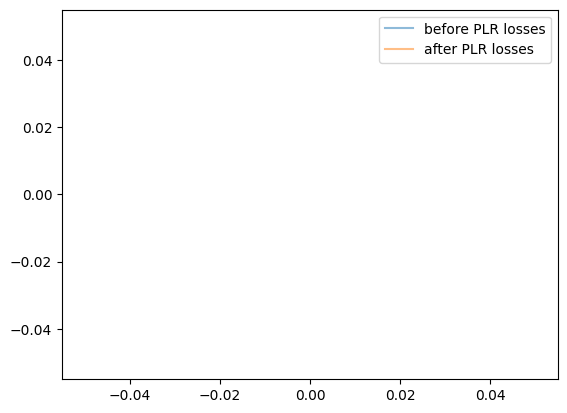

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 162075
Huld fitted coefficients (scaled): [ 3.80376652e-01  1.69670090e-01 -1.69517131e-03  1.21130377e-02
  8.24724694e-03 -2.11327098e-04]
Sodankyla_20deg
-0.33
-------------


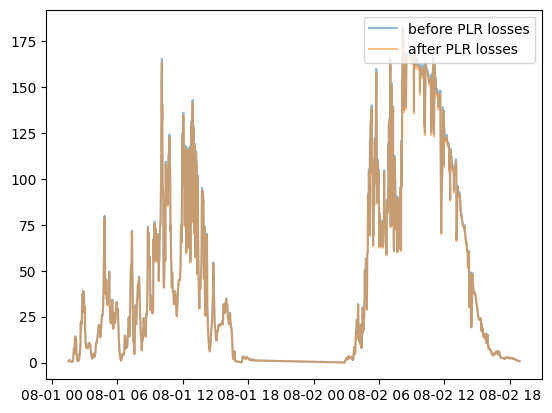

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 183376
Huld fitted coefficients (scaled): [ 2.07119681e-01  5.00672897e-02 -2.38275779e-03  5.78026611e-03
  2.95507114e-03 -1.84215922e-04]
Sodankyla_90deg
-0.33
-------------


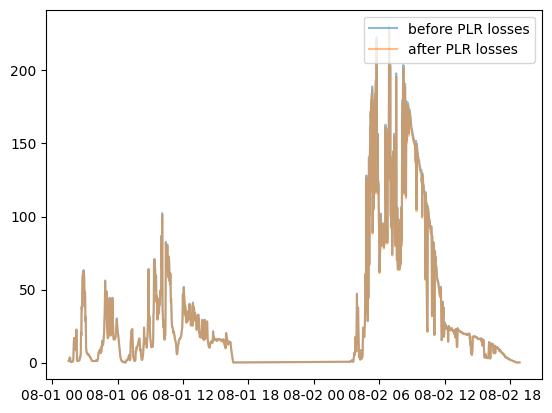

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 35454
Huld fitted coefficients (scaled): [ 1.84920069e-01  5.78765701e-02 -9.11820429e-03 -9.78801390e-03
 -2.35152999e-04  2.88542255e-05]
KTK
-0.33
-------------


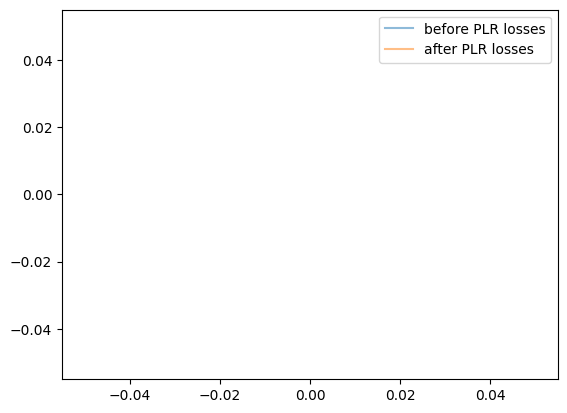

In [11]:
scenario = "scenario_3"

config.set_params_helsinki(scenario)

df_hel_scenario_3 = run_system(
    system_name="Helsinki", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_kuopio(scenario)

df_kuo_scenario_3 = run_system(
    system_name="Kuopio", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_sodankyla_20(scenario)

df_sod20_scenario_3 = run_system(
    system_name="Sodankyla_20deg", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_sodankyla_90(scenario)

df_sod90_scenario_3 = run_system(
    system_name="Sodankyla_90deg", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_turku(scenario)

df_tku_scenario_3 = run_system(
    system_name="KTK", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 177993
Huld fitted coefficients (scaled): [ 1.23209738e-01  5.65834420e-02 -6.17884018e-03 -4.96650318e-03
  6.96989263e-04 -9.68937118e-06]
Helsinki
-0.81
-------------


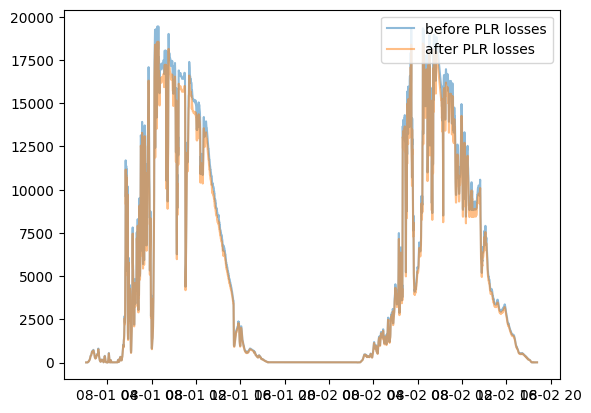

In [10]:
scenario = "scenario_4"

config.set_params_helsinki(scenario)

df_hel_scenario_4 = run_system(
    system_name="Helsinki", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}",
    plr="0.81"
    )


Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 125409
Huld fitted coefficients (scaled): [ 1.21146746e-01  4.10345829e-02 -5.20961109e-03  1.64075478e-04
  1.55951856e-03  5.23720237e-05]
Kuopio
-0.41
-------------


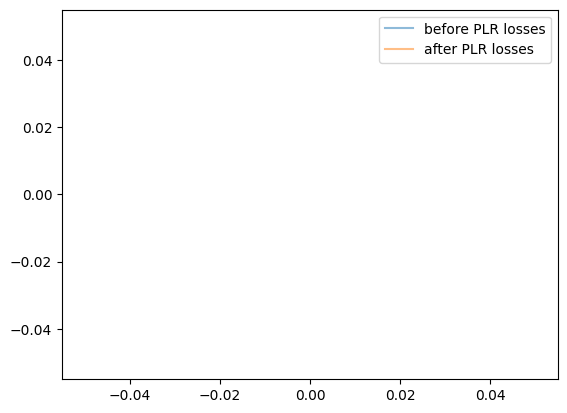

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 162075
Huld fitted coefficients (scaled): [ 3.77902378e-01  1.68726389e-01 -1.65075853e-03  1.21073166e-02
  8.23060661e-03 -2.11675191e-04]
Sodankyla_20deg
-0.86
-------------


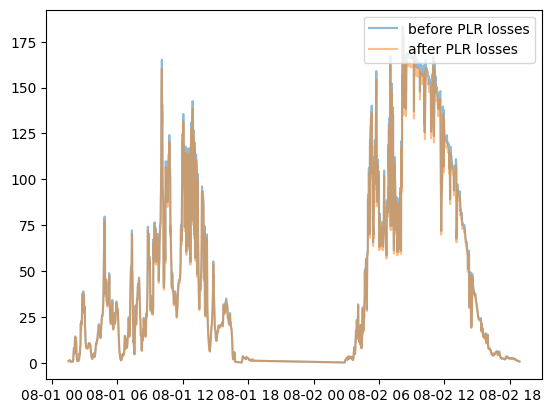

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 183376
Huld fitted coefficients (scaled): [ 2.00713591e-01  4.76846973e-02 -2.34500657e-03  5.69752112e-03
  2.92051024e-03 -1.81865026e-04]
Sodankyla_90deg
-1.35
-------------


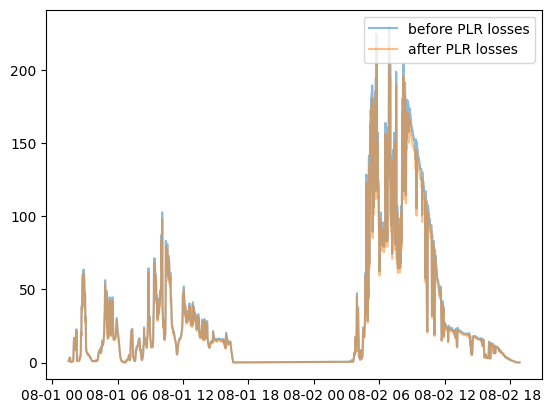

Calculating hgbr model predicions
Calculating Huld model predicions
Training data len: 35454
Huld fitted coefficients (scaled): [ 1.64622095e-01  5.05108450e-02 -8.44173901e-03 -9.19839160e-03
 -2.10712830e-04  1.66934982e-05]
KTK
-2.65
-------------


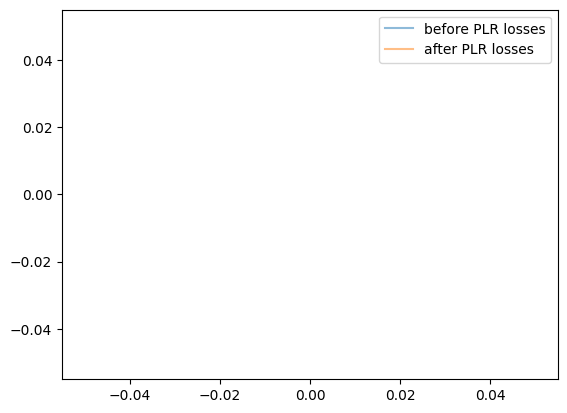

In [13]:
config.set_params_kuopio(scenario)

df_kuo_scenario_4 = run_system(
    system_name="Kuopio", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_sodankyla_20(scenario)

df_sod20_scenario_4 = run_system(
    system_name="Sodankyla_20deg", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_sodankyla_90(scenario)

df_sod90_scenario_4 = run_system(
    system_name="Sodankyla_90deg", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )

config.set_params_turku(scenario)

df_tku_scenario_4 = run_system(
    system_name="KTK", 
    folder=scenario,  
    scenario=scenario,
    model_type_list=["hgbr", "Huld"],
    save_df_path=f"data/with_predictions/{scenario}"
    )